# Linear Probe Scaling Curves: Collect per-experiment metric files and plot

Reads `*.txt` metric files saved by `2026-04-15_15-30_compute_linear_probe_metrics.py` and
plots noise-scaling curves (x = quality, lines = sizes) for each dataset and algorithm.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from tqdm.auto import tqdm

DATA_ROOT = Path('/home/igor/noise_scaling/data')

ALGOS = ['Geneformer', 'PCA', 'RandomProjection', 'SCVI', 'State']
ALGO_ORDER = ['State', 'Geneformer', 'SCVI', 'PCA']

EXPECTED = {
    'PBMC': {
        'sizes': [100, 215, 464, 1000, 2154, 4641, 10000, 21544, 46415, 100000],
        'qualities': [0.0012346, 0.0025982, 0.0054682, 0.0115083, 0.02422, 0.050973, 0.1072766, 0.225772, 0.4751547, 1.0],
        'task': 'regression',
    },
    'larry': {
        'sizes': [100, 215, 464, 1000, 2154, 4641, 10000, 21544, 46415, 100000],
        'qualities': [0.003876, 0.0071835, 0.0133136, 0.0246748, 0.0457311, 0.0847557, 0.1570821, 0.2911284, 0.5395631, 1.0],
        'task': 'regression',
    },
    'merfish': {
        'sizes': [100, 203, 414, 843, 1716, 3494, 7113, 14480, 29475, 60000],
        'qualities': [0.027248, 0.0406617, 0.0606789, 0.0905502, 0.1351267, 0.2016475, 0.3009156, 0.4490518, 0.6701133, 1.0],
        'task': 'regression',
    },
    'shendure': {
        'sizes': [100, 359, 1291, 4641, 16681, 59948, 215443, 774263, 2782559, 10000000],
        'qualities': [0.004, 0.0073875, 0.0136438, 0.0251984, 0.0465384, 0.0859506, 0.1587401, 0.2931733, 0.5414548, 1.0],
        'task': 'classification',
    },
}

# Metrics to look for per task type
REGRESSION_METRICS = ['ridge_mean_r2', 'ridge_mean_mse', 'ridge_mean_mae']
CLASSIFICATION_METRICS = ['knn_accuracy', 'knn_macro_f1', 'logreg_accuracy', 'logreg_macro_f1']

## Collect metric files from disk

In [2]:
from itertools import product
from concurrent.futures import ThreadPoolExecutor
import os

# Build expected grid: one row per (dataset, algo, size, quality) with the metric files we expect
expected_rows = []
for ds, cfg in EXPECTED.items():
    metric_names = CLASSIFICATION_METRICS if cfg['task'] == 'classification' else REGRESSION_METRICS
    for algo, size, quality in product(ALGOS, cfg['sizes'], cfg['qualities']):
        model_dir = DATA_ROOT / ds / str(size) / str(quality) / 'results' / algo / 'model'
        # We consider the experiment "found" if at least one metric file exists
        expected_rows.append({
            'dataset': ds, 'algorithm': algo, 'size': size, 'quality': quality,
            'task': cfg['task'], 'model_dir': str(model_dir),
            'metric_names': metric_names,
        })

df_expected = pd.DataFrame(expected_rows)
print(f'Total expected experiments: {len(df_expected)}')

# Check which have at least one metric .txt file
def _has_any_metric(row):
    d = Path(row['model_dir'])
    return any((d / f'{m}.txt').exists() for m in row['metric_names'])

with ThreadPoolExecutor(max_workers=128) as pool:
    df_expected['exists'] = list(tqdm(
        pool.map(lambda i: _has_any_metric(df_expected.iloc[i]), range(len(df_expected))),
        total=len(df_expected), desc='Scanning'))

print(f"Found: {df_expected['exists'].sum()}, Missing: {(~df_expected['exists']).sum()}")

Total expected experiments: 2000


Scanning: 100%|██████████| 2000/2000 [00:00<00:00, 456125.71it/s]

Found: 1802, Missing: 198


In [3]:
# Completeness table: found / expected / missing per dataset x algorithm
pivot = df_expected.groupby(['dataset', 'algorithm'])['exists'].agg(['sum', 'count'])
pivot.columns = ['found', 'expected']
pivot['missing'] = pivot['expected'] - pivot['found']
pivot = pivot.astype(int)

pivot_wide = pivot.unstack('algorithm', fill_value=0).sort_index()
pivot_wide = pivot_wide.reindex(columns=pivot_wide.columns.reindex(
    ALGO_ORDER, level='algorithm')[0])
display(pivot_wide)

found                      expected                      missing  \
algorithm State Geneformer SCVI  PCA    State Geneformer SCVI  PCA   State   
dataset                                                                      
PBMC        100        100  100  100      100        100  100  100       0   
larry         1        100  100  100      100        100  100  100      99   
merfish     100        100  100  100      100        100  100  100       0   
shendure      1        100  100  100      100        100  100  100      99   

                               
algorithm Geneformer SCVI PCA  
dataset                        
PBMC               0    0   0  
larry              0    0   0  
merfish            0    0   0  
shendure           0    0   0

## Read metric values

In [4]:
# Read actual metric values from found experiments
rows = []
df_found = df_expected[df_expected['exists']].copy()
for _, exp in tqdm(df_found.iterrows(), total=len(df_found), desc='Reading metrics'):
    model_dir = Path(exp['model_dir'])
    row = {
        'dataset': exp['dataset'], 'algorithm': exp['algorithm'],
        'size': exp['size'], 'quality': exp['quality'], 'task': exp['task'],
    }
    for metric in exp['metric_names']:
        fpath = model_dir / f'{metric}.txt'
        if fpath.exists():
            row[metric] = float(fpath.read_text().strip())
        else:
            row[metric] = np.nan
    rows.append(row)

df = pd.DataFrame(rows)
print(f'Collected {len(df)} results')
df.head()

Reading metrics: 100%|██████████| 1802/1802 [00:00<00:00, 4692.28it/s]

Collected 1802 results


,dataset,algorithm,size,quality,task,ridge_mean_r2,ridge_mean_mse,ridge_mean_mae,knn_accuracy,knn_macro_f1,logreg_accuracy,logreg_macro_f1
0,PBMC,Geneformer,100,0.001235,regression,-0.162861,7532.277615,18.189933,NaN,NaN,NaN,NaN
1,PBMC,Geneformer,100,0.002598,regression,-0.209871,7303.046655,17.456674,NaN,NaN,NaN,NaN
2,PBMC,Geneformer,100,0.005468,regression,-0.016518,6923.395961,16.990701,NaN,NaN,NaN,NaN
3,PBMC,Geneformer,100,0.011508,regression,0.111950,6654.303639,16.531380,NaN,NaN,NaN,NaN
4,PBMC,Geneformer,100,0.024220,regression,0.110355,6481.801421,16.179610,NaN,NaN,NaN,NaN


## Noise scaling curves (metric vs quality, one line per size)

In [5]:
import matplotlib.ticker as mticker

DS_ORDER = ['PBMC', 'larry', 'merfish', 'shendure']

# Map dataset -> list of (metric_col, display_label) to plot
METRIC_MAP = {
    'PBMC': [('ridge_mean_r2', 'Ridge Mean R²'), ('ridge_mean_mse', 'Ridge Mean MSE'), ('ridge_mean_mae', 'Ridge Mean MAE')],
    'larry': [('ridge_mean_r2', 'Ridge Mean R²'), ('ridge_mean_mse', 'Ridge Mean MSE'), ('ridge_mean_mae', 'Ridge Mean MAE')],
    'merfish': [('ridge_mean_r2', 'Ridge Mean R²'), ('ridge_mean_mse', 'Ridge Mean MSE'), ('ridge_mean_mae', 'Ridge Mean MAE')],
    'shendure': [('knn_accuracy', 'KNN Accuracy'), ('knn_macro_f1', 'KNN Macro F1'),
                 ('logreg_accuracy', 'LogReg Accuracy'), ('logreg_macro_f1', 'LogReg Macro F1')],
}


def _fmt_size(sz):
    """Human-readable size label: 100, 1k, 10k, 1M, 10M, etc."""
    if sz >= 1_000_000:
        return f'{sz/1_000_000:.0f}M' if sz % 1_000_000 == 0 else f'{sz/1_000_000:.1f}M'
    if sz >= 1_000:
        return f'{sz/1_000:.0f}k' if sz % 1_000 == 0 else f'{sz/1_000:.1f}k'
    return str(sz)


def plot_scaling_curves(df, metric_col, metric_label, ds_order=DS_ORDER, algo_order=ALGO_ORDER,
                        lower_is_better=False, pct=False):
    """One figure: rows=datasets, cols=algorithms. X=quality, lines=sizes.
    Each dataset row gets its own colormap range and legend.
    - Log-log axes by default.
    - If lower_is_better=True, invert y-axis so "improving" always goes up.
    - If pct=True, use linear y-axis with percentage labels (for [0,1] metrics)."""
    datasets = [d for d in ds_order if d in df['dataset'].unique() and metric_col in df.columns]
    datasets = [d for d in datasets if df[(df['dataset'] == d)][metric_col].notna().any()]
    algorithms = [a for a in algo_order if a in df['algorithm'].unique()]
    if not datasets or not algorithms:
        return None

    n_rows, n_cols = len(datasets), len(algorithms)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols + 1.6, 3.5 * n_rows + 0.8),
                             squeeze=False, sharex=False)

    for i in range(n_rows):
        for j in range(1, n_cols):
            axes[i, j].sharey(axes[i, 0])

    # Per-dataset size lists and colormaps
    ds_sizes = {ds: sorted(df[df['dataset'] == ds]['size'].unique()) for ds in datasets}
    ds_norms = {}
    for ds, sizes in ds_sizes.items():
        if len(sizes) > 0:
            ds_norms[ds] = mcolors.LogNorm(vmin=min(sizes), vmax=max(sizes))
    cmap = plt.cm.viridis

    for i, ds in enumerate(datasets):
        norm = ds_norms.get(ds)
        for j, algo in enumerate(algorithms):
            ax = axes[i, j]
            sub = df[(df['dataset'] == ds) & (df['algorithm'] == algo)].dropna(subset=[metric_col])

            if sub.empty:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                        transform=ax.transAxes, color='gray', fontsize=10)
            else:
                for sz in sorted(sub['size'].unique()):
                    color = cmap(norm(sz))
                    sz_df = sub[sub['size'] == sz].sort_values('quality')
                    y = sz_df[metric_col] * 100 if pct else sz_df[metric_col]
                    ax.plot(sz_df['quality'], y,
                            marker='o', markersize=3, linewidth=1, color=color, alpha=0.85,
                            label=_fmt_size(sz))

            ax.set_xscale('log')
            if pct:
                ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
            else:
                ax.set_yscale('log')
            if lower_is_better:
                ax.invert_yaxis()
            if i == n_rows - 1:
                ax.set_xlabel('Quality', fontsize=10)
            if j == 0:
                arrow = '  \u2191 better' if lower_is_better else ''
                ax.set_ylabel(f'{ds} — {metric_label}{arrow}', fontsize=10)
            if i == 0:
                ax.set_title(algo, fontsize=12, fontweight='bold')
            ax.tick_params(labelsize=8)
            if j > 0:
                ax.tick_params(labelleft=False)

        # Add legend to the right of the last column for this row
        last_ax = axes[i, n_cols - 1]
        handles, labels = last_ax.get_legend_handles_labels()
        if handles:
            last_ax.legend(handles, labels, title='# cells', fontsize=6,
                           title_fontsize=7, loc='center left',
                           bbox_to_anchor=(1.02, 0.5), borderaxespad=0,
                           frameon=True, framealpha=0.8)

    subtitle = ' (inverted: lower = better)' if lower_is_better else ''
    fig.suptitle(f'{metric_label} vs Quality{subtitle}', fontsize=14, fontweight='bold')
    fig.tight_layout(rect=[0, 0.01, 0.92, 0.96])
    plt.show()
    return fig

In [6]:
# (metric_col, display_label, lower_is_better, pct)
REGRESSION_METRICS_DISPLAY = [
    ('ridge_mean_mse', 'Ridge Mean MSE', True, False),
]
CLASSIFICATION_METRICS_DISPLAY = [
    ('logreg_accuracy', 'LogReg Accuracy', False, False),
]

### Regression metrics (PBMC, larry, merfish) — MSE & MAE (y-axis inverted)

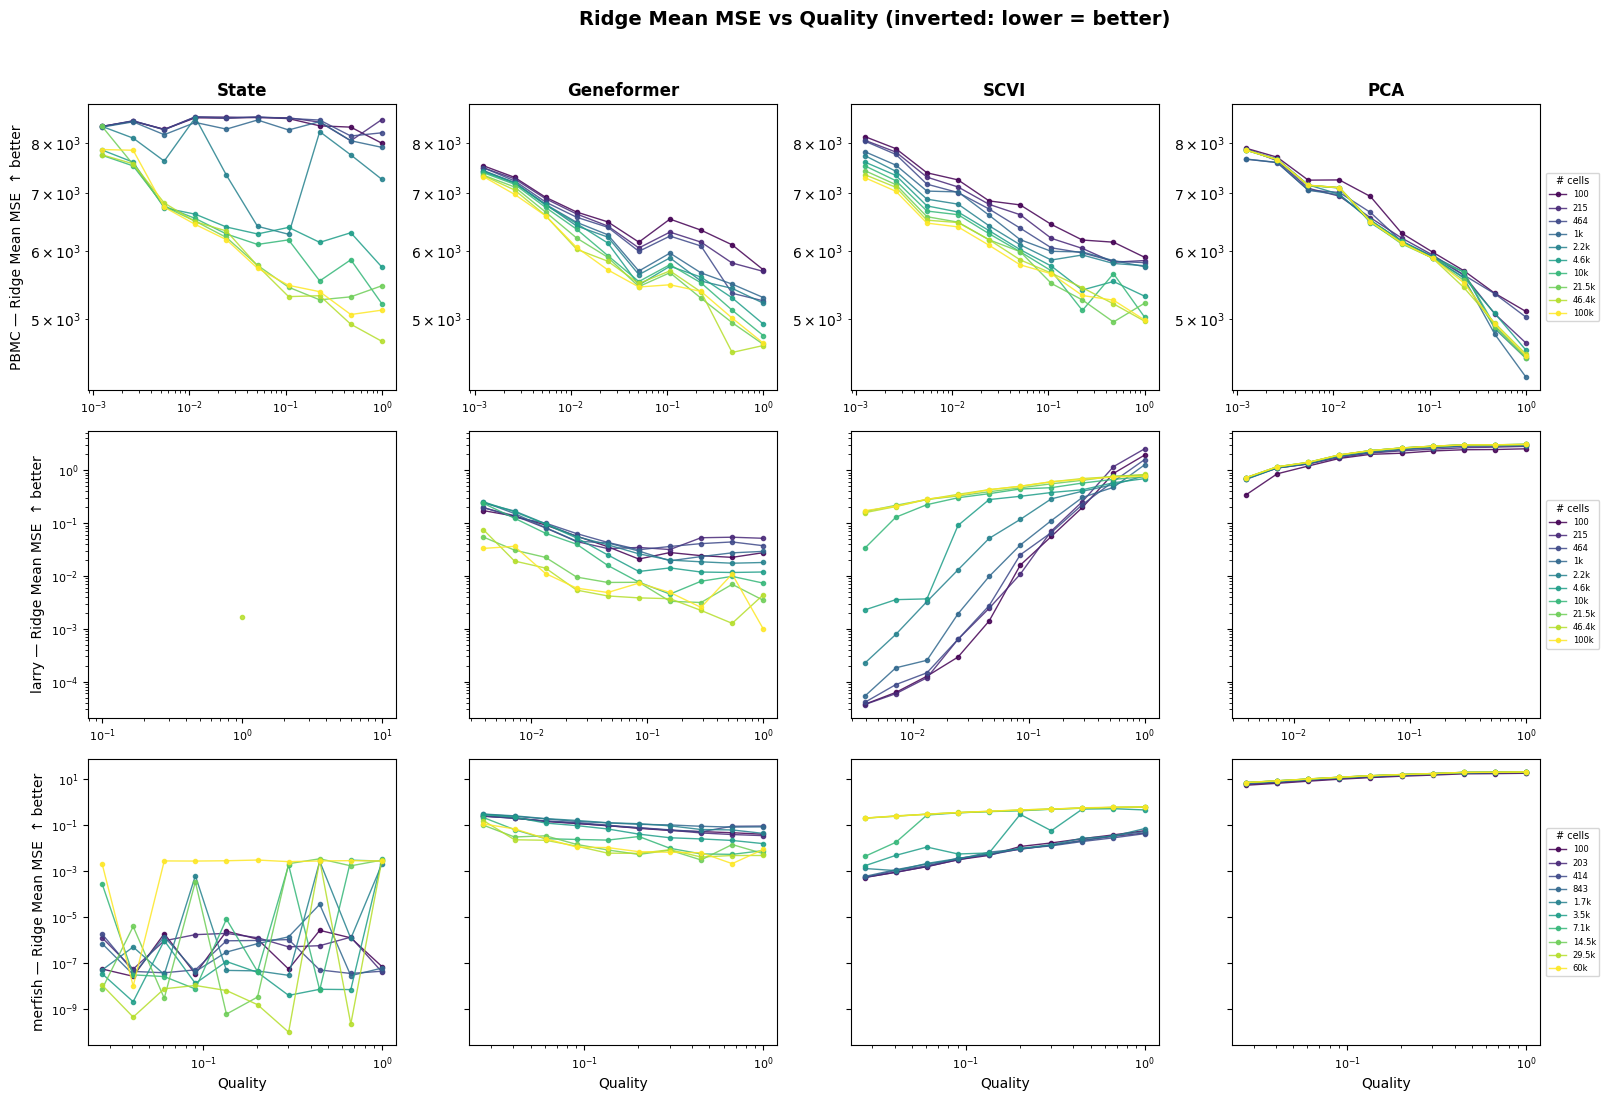

In [7]:
for metric_col, metric_label, lib, pct in REGRESSION_METRICS_DISPLAY:
    plot_scaling_curves(df, metric_col, metric_label,
                        ds_order=['PBMC', 'larry', 'merfish'], lower_is_better=lib, pct=pct)

### Classification metrics (shendure)

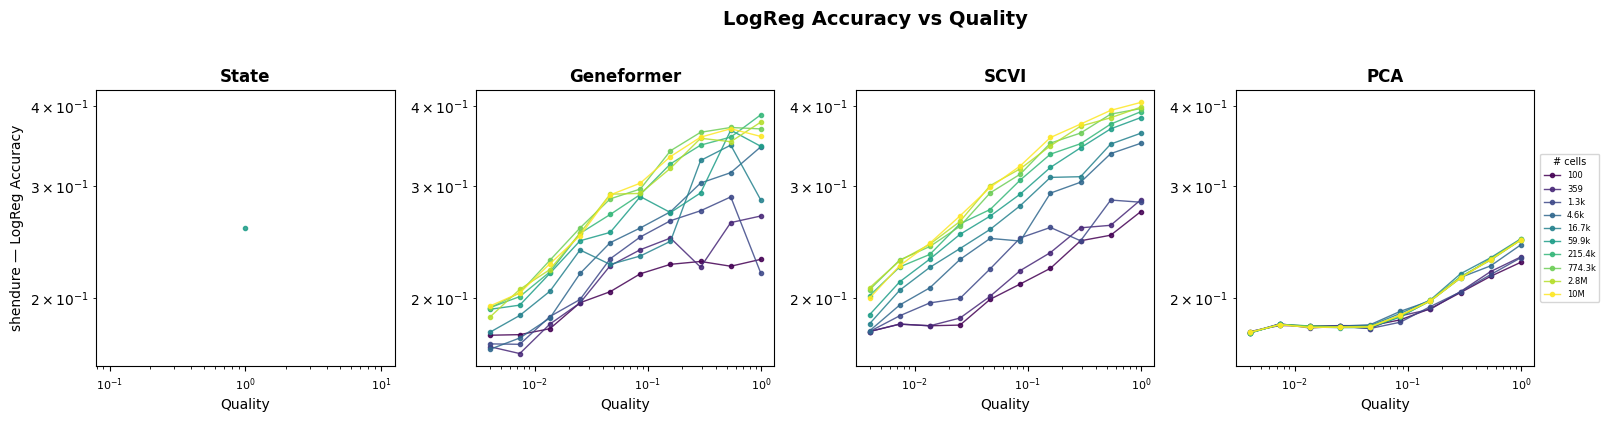

In [8]:
for metric_col, metric_label, lib, pct in CLASSIFICATION_METRICS_DISPLAY:
    plot_scaling_curves(df, metric_col, metric_label,
                        ds_order=['shendure'], lower_is_better=lib, pct=pct)